<a href="https://colab.research.google.com/github/GabriellaJovanka/churn-customer--prediction/blob/main/ChurnPredict_Draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Ujian Akhir Semester — Bengkel Koding Data Science

---

**Topik:** Prediksi Customer Churn — Sales and Marketing Dataset  
**Jumlah Sampel:** 15.000 records | **Jumlah Kolom:** 30  

---

###Nama : Gabriella Jovanka Bustan
###NIM : A11.2023.14861

---

## 📦 0. Import Library

In [1]:
#Standard & Scientific
import pandas as pd
import numpy as np
import json, warnings, os
warnings.filterwarnings('ignore')

#Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

#Model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# ─── Evaluasi & Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

#Deployment
import joblib

#Settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
SEED = 42
TEST_SIZE = 0.2

print("✅ Semua library berhasil diimport!")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   sklearn    : {__import__('sklearn').__version__}")

✅ Semua library berhasil diimport!
   pandas     : 2.2.2
   numpy      : 2.0.2
   sklearn    : 1.6.1


---
## 📊 1. Exploratory Data Analysis (EDA)

### 1.1 Load Dataset

In [2]:
FILE_PATH = 'sales_marketing_customer_dataset.csv'

df = pd.read_csv(FILE_PATH)

print(f"✅ Dataset berhasil dimuat!")
print(f"   Baris   : {df.shape[0]:,}")
print(f"   Kolom   : {df.shape[1]}")

✅ Dataset berhasil dimuat!
   Baris   : 15,000
   Kolom   : 30


### 1.2 Lima Baris Pertama, Info, & Statistik Deskriptif

In [3]:
#5 Baris Pertama
print("=" * 60)
print("5 BARIS PERTAMA DATASET")
print("=" * 60)
display(df.head())

5 BARIS PERTAMA DATASET


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
#Informasi Dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_ses

In [5]:
#Statistik Deskriptif
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
display(df.describe().T.style.background_gradient(cmap='Blues'))

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.000000,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.000000,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.000000,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.000000,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.000000,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.000000,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.000000,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.000000,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.000000,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.000000,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


### 1.3 Analisis Missing Value

⚠️  Kolom dengan missing value: 5


,Missing Count,Missing (%)
coupon_code,6133,40.886667
age,1200,8.000000
total_spent,1050,7.000000
gender,738,4.920000
satisfaction_score,702,4.680000


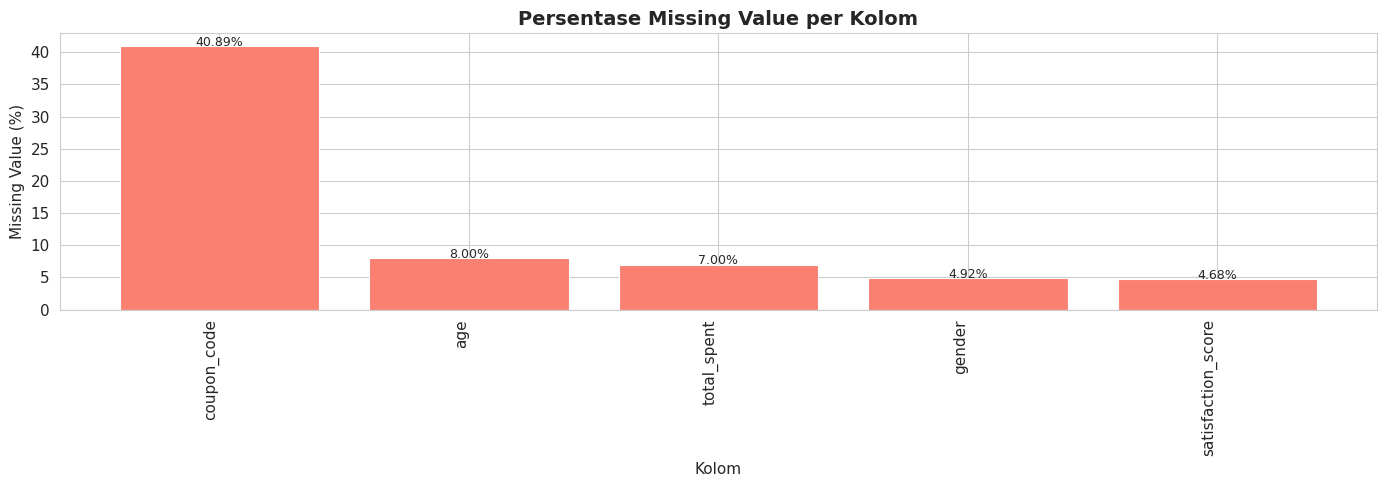

In [6]:
#Hitung Missing Value
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)':   missing_pct
}).sort_values('Missing (%)', ascending=False)

# Tampilkan tabel
has_missing = missing_df[missing_df['Missing Count'] > 0]
if has_missing.empty:
    print("✅ Tidak ada missing value pada dataset!")
else:
    print(f"⚠️  Kolom dengan missing value: {len(has_missing)}")
    display(has_missing.style.background_gradient(cmap='Reds', subset=['Missing (%)']))

#Visualisasi Bar Chart
fig, ax = plt.subplots(figsize=(14, 5))

if has_missing.empty:
    ax.text(0.5, 0.5, '✅ Tidak Ada Missing Value',
            ha='center', va='center', fontsize=16, color='green',
            transform=ax.transAxes)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
else:
    cols_mv = missing_pct[missing_pct > 0].sort_values(ascending=False)
    bars = ax.bar(cols_mv.index, cols_mv.values, color='salmon', edgecolor='white', linewidth=0.8)
    ax.set_title('Persentase Missing Value per Kolom', fontsize=14, fontweight='bold')
    ax.set_xlabel('Kolom'); ax.set_ylabel('Missing Value (%)')
    ax.set_xticks(range(len(cols_mv))); ax.set_xticklabels(cols_mv.index, rotation=90, ha='right')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 1.4 Distribusi Variabel Target (Churn)

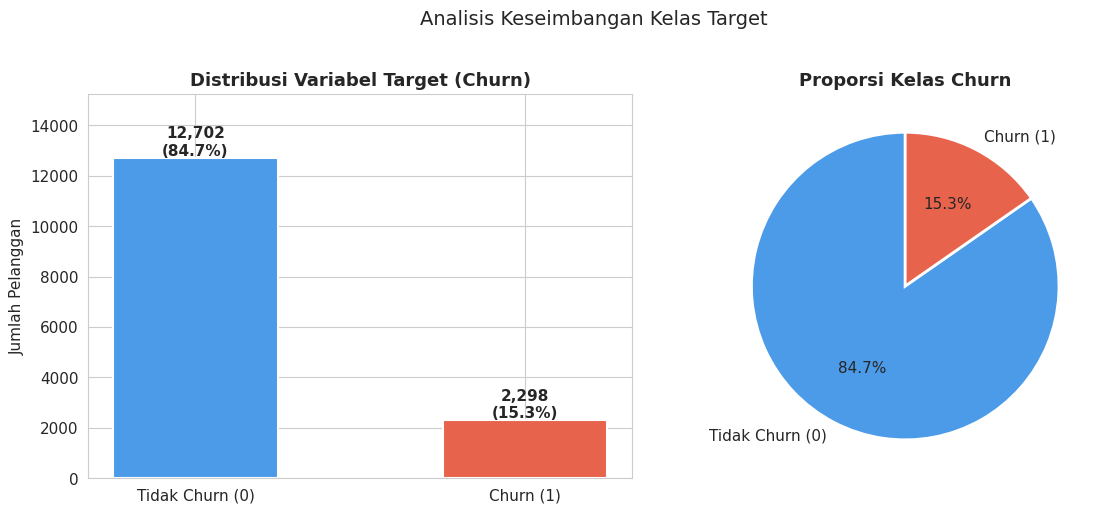


📌 Distribusi Kelas:
   Churn = 0 (Tidak Churn) : 12,702 (84.68%)
   Churn = 1 (Churn)       : 2,298 (15.32%)
   Rasio kelas             : 5.53:1
   ⚠️  Dataset mengalami class imbalance — pertimbangkan SMOTE/class_weight.


In [7]:
#Distribusi Churn
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4C9BE8', '#E8634C']
labels = ['Tidak Churn (0)', 'Churn (1)']
bars = axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Distribusi Variabel Target (Churn)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, churn_counts.max() * 1.2)
for bar, cnt, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Keseimbangan Kelas Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📌 Distribusi Kelas:")
print(f"   Churn = 0 (Tidak Churn) : {churn_counts[0]:,} ({churn_pct[0]:.2f}%)")
print(f"   Churn = 1 (Churn)       : {churn_counts[1]:,} ({churn_pct[1]:.2f}%)")
ratio = churn_counts.max() / churn_counts.min()
print(f"   Rasio kelas             : {ratio:.2f}:1")
if ratio > 2:
    print("   ⚠️  Dataset mengalami class imbalance — pertimbangkan SMOTE/class_weight.")
else:
    print("   ✅ Dataset relatif seimbang.")

### 1.5 Heatmap Korelasi Fitur Numerik

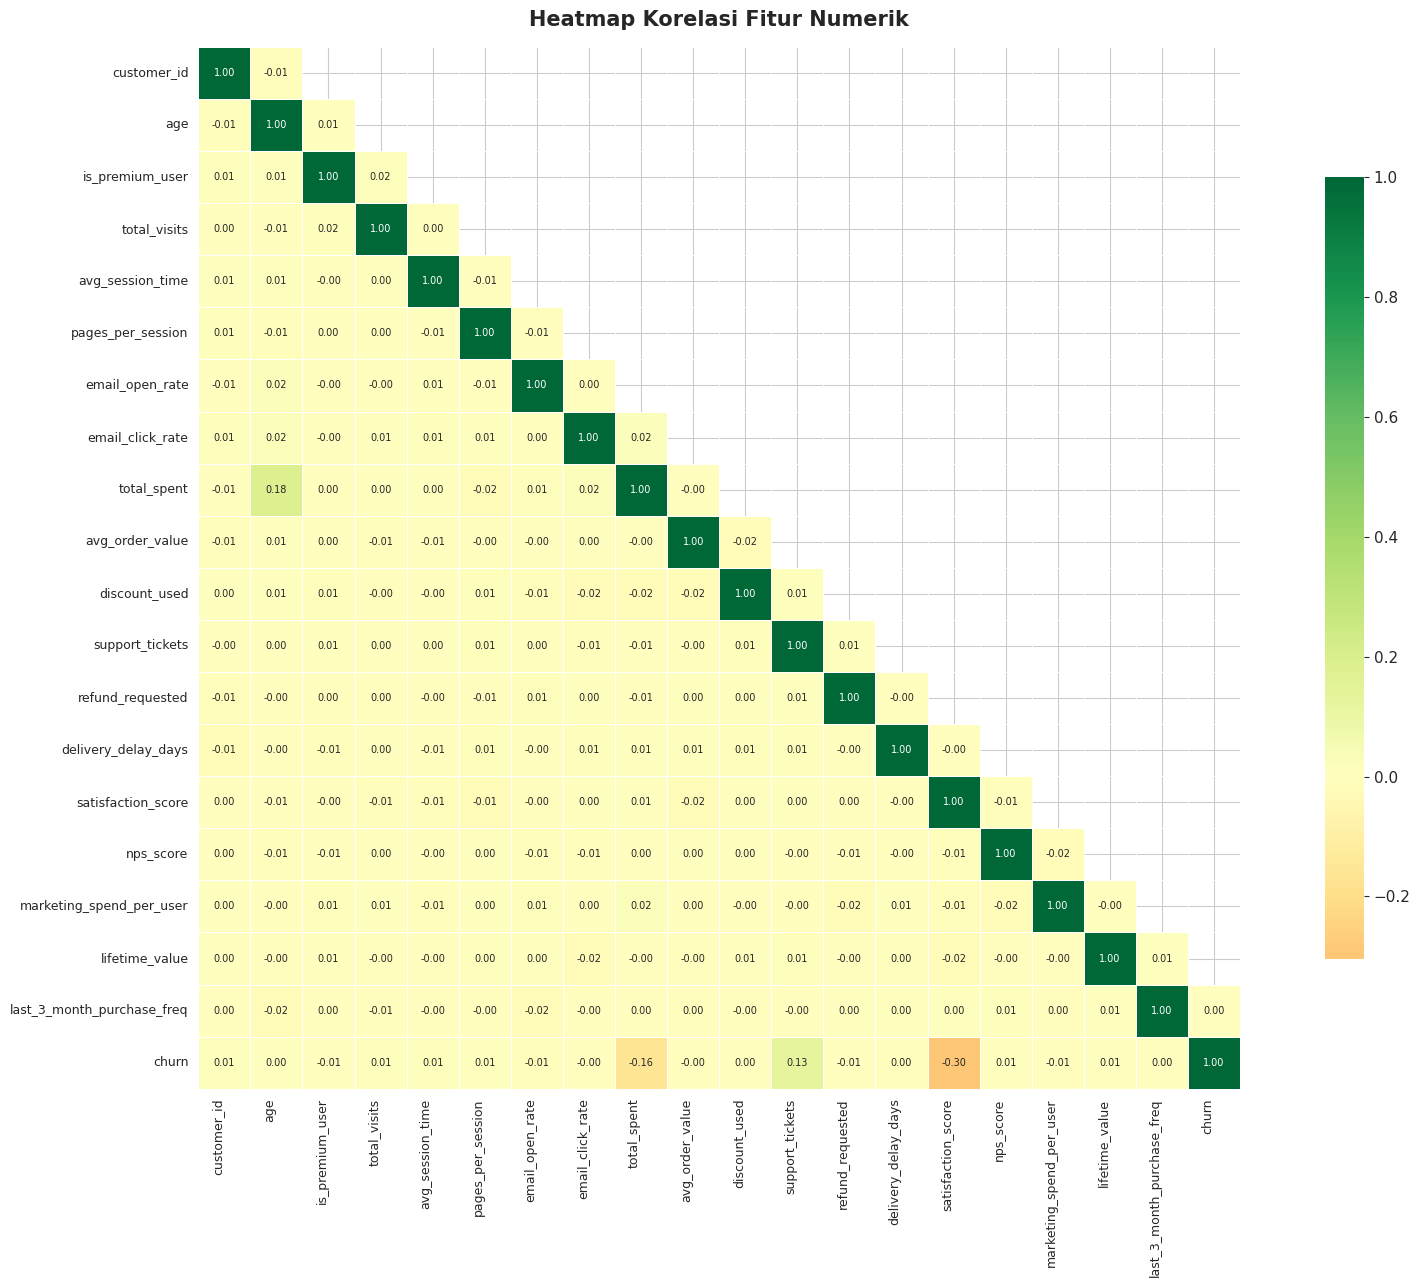


📌 Korelasi Teratas dengan Variabel Churn:


,|Korelasi| dengan Churn
satisfaction_score,0.303588
total_spent,0.163279
support_tickets,0.127910
total_visits,0.013212
customer_id,0.012208
avg_session_time,0.012198
email_open_rate,0.008439
marketing_spend_per_user,0.007315
refund_requested,0.006959
lifetime_value,0.006250


In [8]:
#Heatmap Korelasi
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(18, 13))
mask = np.tril(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr,
            mask=~mask,          # tampilkan segitiga bawah
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.4,
            cbar_kws={'shrink': 0.75},
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

#Top korelasi dengan churn
print("\n📌 Korelasi Teratas dengan Variabel Churn:")
churn_corr = corr['churn'].drop('churn').abs().sort_values(ascending=False)
display(churn_corr.head(10).rename('|Korelasi| dengan Churn')
         .to_frame().style.bar(color='steelblue'))

---
## 🤖 2. Direct Modeling

### 2.1 Persiapan Fitur & Target (Direct)

In [9]:
# Persiapan Direct Modeling
# Pada direct modeling, hanya kolom bertipe numerik (int64/float64) yang digunakan,
# karena sklearn tidak bisa langsung menangani kolom object/datetime.
# Kolom non-numerik & ID di-drop (preprocessing minimal).
# Tidak ada encoding, scaling, imputasi.

df_direct = df.copy()

# Drop kolom non-numerik & ID
drop_direct = ['customer_id', 'gender', 'country', 'city', 'signup_date',
               'last_purchase_date', 'acquisition_channel', 'device_type',
               'subscription_type', 'coupon_code', 'payment_method']
df_direct.drop(columns=[c for c in drop_direct if c in df_direct.columns], inplace=True)

# Isi NaN numerik dengan median (agar tidak error saat fit)
for col in df_direct.columns:
    if df_direct[col].isnull().any():
        df_direct[col].fillna(df_direct[col].median(), inplace=True)

X_direct = df_direct.drop(columns=['churn'])
y_direct  = df_direct['churn']

print(f"Shape X (direct) : {X_direct.shape}")
print(f"Shape y (direct) : {y_direct.shape}")
print(f"\nFitur yang digunakan ({len(X_direct.columns)}):")
print(X_direct.columns.tolist())

Shape X (direct) : (15000, 18)
Shape y (direct) : (15000,)

Fitur yang digunakan (18):
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


### 2.2 Train–Test Split

In [10]:
# Train–Test Split 80:20
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_direct, y_direct,
    test_size=TEST_SIZE, random_state=SEED, stratify=y_direct
)

print(f"Data Latih : {X_tr_d.shape[0]:,} samples ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Data Uji   : {X_te_d.shape[0]:,} samples ({TEST_SIZE*100:.0f}%)")
print(f"Distribusi y_train : {dict(y_tr_d.value_counts())}")
print(f"Distribusi y_test  : {dict(y_te_d.value_counts())}")

Data Latih : 12,000 samples (80%)
Data Uji   : 3,000 samples (20%)
Distribusi y_train : {0: np.int64(10162), 1: np.int64(1838)}
Distribusi y_test  : {0: np.int64(2540), 1: np.int64(460)}


### 2.3 Helper Function: Evaluasi Model

In [11]:
# Helper fungsi evaluasi
results_all = []   # simpan semua hasil untuk perbandingan akhir

def evaluate_model(model, X_test, y_test, model_name, scenario):
    y_pred = model.predict(X_test)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1    = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm    = confusion_matrix(y_test, y_pred)

    print(f"\n{'─'*55}")
    print(f"  MODEL    : {model_name}")
    print(f"  SKENARIO : {scenario}")
    print(f"{'─'*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=['Tidak Churn', 'Churn'],
                                 zero_division=0))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'],
                linewidths=1, linecolor='white')
    ax.set_title(f'Confusion Matrix\n{model_name} — {scenario}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

    row = {'Model': model_name, 'Scenario': scenario,
           'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    results_all.append(row)
    return row

print("✅ Fungsi evaluate_model siap digunakan.")

✅ Fungsi evaluate_model siap digunakan.


### 2.4 Training & Evaluasi (Direct)

⏳ Training Logistic Regression (Direct)...

───────────────────────────────────────────────────────
  MODEL    : Logistic Regression
  SKENARIO : Direct
───────────────────────────────────────────────────────
  Accuracy  : 0.8437
  Precision : 0.8009
  Recall    : 0.8437
  F1-Score  : 0.8057

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91      2540
       Churn       0.47      0.14      0.21       460

    accuracy                           0.84      3000
   macro avg       0.66      0.55      0.56      3000
weighted avg       0.80      0.84      0.81      3000



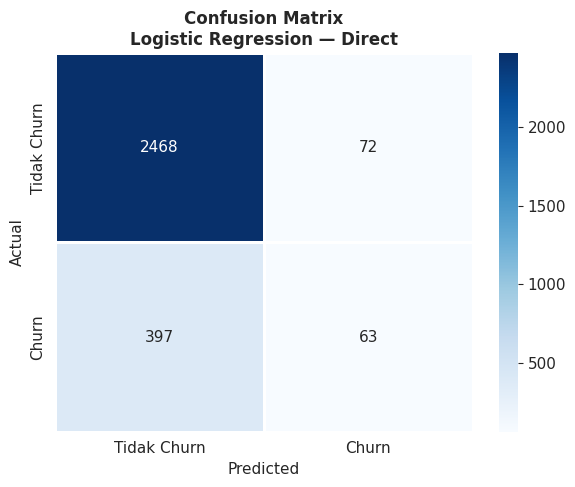

{'Model': 'Logistic Regression',
 'Scenario': 'Direct',
 'Accuracy': 0.8436666666666667,
 'Precision': 0.8009005235602095,
 'Recall': 0.8436666666666667,
 'F1-Score': 0.8056707115778782}

In [12]:
# Model 1: Logistic Regression (Konvensional)
print("⏳ Training Logistic Regression (Direct)...")
lr_d = LogisticRegression(max_iter=1000, random_state=SEED)
lr_d.fit(X_tr_d, y_tr_d)
evaluate_model(lr_d, X_te_d, y_te_d, "Logistic Regression", "Direct")

⏳ Training Random Forest (Direct)...

───────────────────────────────────────────────────────
  MODEL    : Random Forest
  SKENARIO : Direct
───────────────────────────────────────────────────────
  Accuracy  : 0.8470
  Precision : 0.8313
  Recall    : 0.8470
  F1-Score  : 0.8372

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.89      0.93      0.91      2540
       Churn       0.50      0.37      0.43       460

    accuracy                           0.85      3000
   macro avg       0.70      0.65      0.67      3000
weighted avg       0.83      0.85      0.84      3000



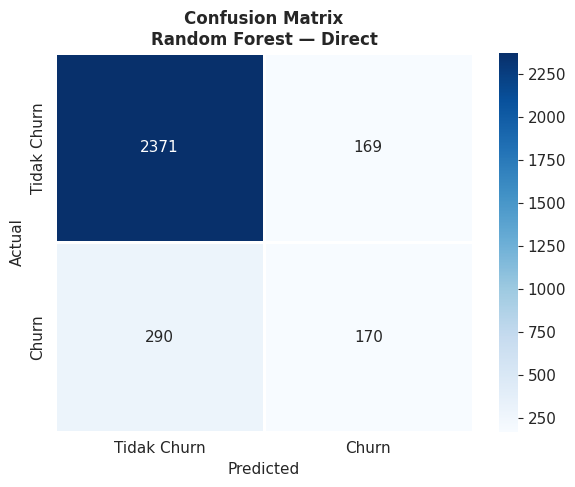

{'Model': 'Random Forest',
 'Scenario': 'Direct',
 'Accuracy': 0.847,
 'Precision': 0.8312884126556543,
 'Recall': 0.847,
 'F1-Score': 0.8371946475105034}

In [13]:
# Model 2: Random Forest (Ensemble Bagging)
print("⏳ Training Random Forest (Direct)...")
rf_d = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_d.fit(X_tr_d, y_tr_d)
evaluate_model(rf_d, X_te_d, y_te_d, "Random Forest", "Direct")

⏳ Training Voting Classifier (Direct) — ini mungkin memerlukan beberapa menit...

───────────────────────────────────────────────────────
  MODEL    : Voting Classifier
  SKENARIO : Direct
───────────────────────────────────────────────────────
  Accuracy  : 0.8457
  Precision : 0.7880
  Recall    : 0.8457
  F1-Score  : 0.7837

  Classification Report:
              precision    recall  f1-score   support

 Tidak Churn       0.85      0.99      0.92      2540
       Churn       0.45      0.03      0.05       460

    accuracy                           0.85      3000
   macro avg       0.65      0.51      0.48      3000
weighted avg       0.79      0.85      0.78      3000



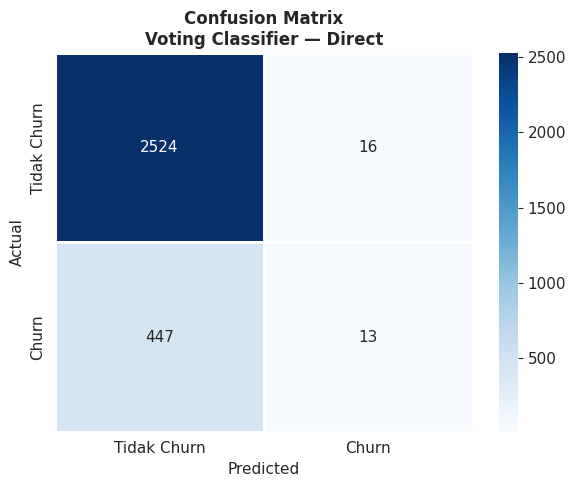

{'Model': 'Voting Classifier',
 'Scenario': 'Direct',
 'Accuracy': 0.8456666666666667,
 'Precision': 0.7880175799007263,
 'Recall': 0.8456666666666667,
 'F1-Score': 0.7836876831946815}

In [14]:
# Model 3: Voting Classifier (Ensemble Voting)
# Kombinasi: Logistic Regression + SVM + KNN
print("⏳ Training Voting Classifier (Direct) — ini mungkin memerlukan beberapa menit...")

estimators_d = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=SEED)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=SEED)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
vc_d = VotingClassifier(estimators=estimators_d, voting='soft', n_jobs=-1)
vc_d.fit(X_tr_d, y_tr_d)
evaluate_model(vc_d, X_te_d, y_te_d, "Voting Classifier", "Direct")

In [15]:
# Ringkasan Direct Modeling
df_direct_results = pd.DataFrame([r for r in results_all if r['Scenario'] == 'Direct'])
print("\n" + "="*55)
print("  RINGKASAN DIRECT MODELING")
print("="*55)
display(df_direct_results.set_index('Model').drop(columns='Scenario')
          .style.highlight_max(color='#c6efce', axis=0)
          .format('{:.4f}'))


  RINGKASAN DIRECT MODELING


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8437,0.8009,0.8437,0.8057
Random Forest,0.8470,0.8313,0.8470,0.8372
Voting Classifier,0.8457,0.7880,0.8457,0.7837
